# Example-13: Mean spectrum

In [1]:
# Import

import numpy
import torch
import nufft
import yaml

import sys
sys.path.append('..')

from harmonica.util import LENGTH
from harmonica.statistics import weighted_mean, weighted_variance
from harmonica.window import Window
from harmonica.data import Data
from harmonica.frequency import Frequency
from harmonica.filter import Filter

import matplotlib.pyplot as plt

torch.set_printoptions(precision=12, sci_mode=True)
print(torch.cuda.is_available())
print(torch.get_num_threads())

True
16


In [2]:
# Set data type and device

dtype = torch.float64
device = torch.device('cpu')

Window(4096, 'cosine_window', 1.0)
Data(54, Window(4096, 'cosine_window', 1.0))
Frequency(Data(54, Window(4096, 'cosine_window', 1.0)), f_range=(0.0, 0.5))


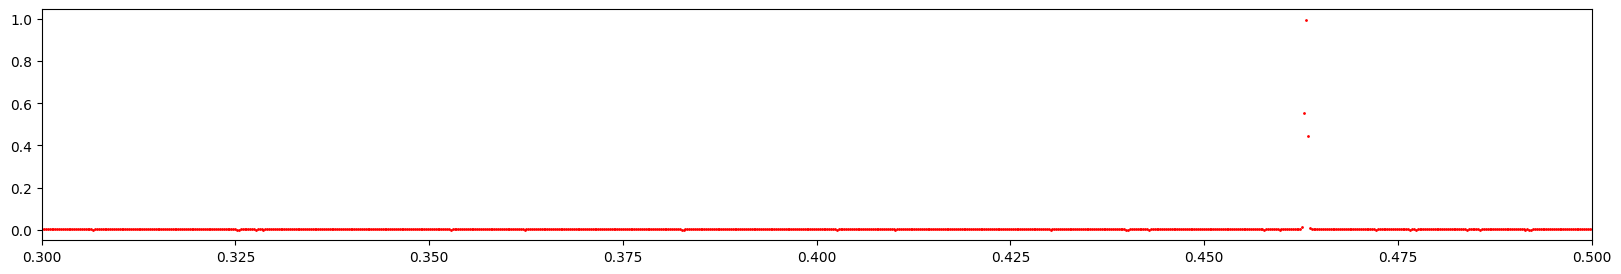

In [3]:
# Set window

w = Window(4096, name='cosine_window', order=1.0, dtype=dtype, device=device)
print(w)

# Load TbT data from file and add noise

d = Data.from_file(54, w, '../virtual_tbt.npy')
s = 1.0E-4*torch.ones(54, dtype=dtype, device=device)
d.add_noise(s)
print(d)

# Apply window (note, window is applied to work)

d.window_remove_mean()
d.window_apply()

# Initialize Frequency instance

f = Frequency(d)
print(f)

# Compute frequencies
# self.frequency container is used for normalization of each signal spectrum

f('parabola')

# Compute mean spectrum
# Note, spectra are not recomputed, normalization and averaging is performed

grid, spectrum = f.compute_mean_spectrum(log=False)

# Plot mean spectrum

plt.figure(figsize=(20, 3))
plt.xlim(0.3, 0.5)
plt.scatter(grid.cpu(), spectrum.cpu(), s=1, c='r')
plt.show()

# Clean

del w
del d
del f
del grid, spectrum
if device != torch.device('cpu'):
    torch.cuda.synchronize()
    torch.cuda.empty_cache()